# Ultimate Eval — Regression Testing hệ thống Hybrid Navigation

Hệ thống: **SLAM map → A\* (inflate) → Mission Controller (huỷ trạm hẹp) →
RL/pursuit local → Safety Shield (né người) → Dynamic Replanning**.

Chạy trên **map cũ** (test_c_curve, test_s_curve, test_u_turn) + **map mới**
(apartment_complex, bản đồ robot tự quét) để xác nhận **tương thích ngược** và độ
"trâu bò" trên địa hình lạ.

## 1. Setup + hàm tiện ích (render + đếm né người)

In [1]:
import os, sys, math
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib.patches as mp
from IPython.display import Image, display
from fixed_maps import build_map
from hybrid_controller import MissionController
from pedestrians2d import Pedestrians
import nav_demo as nd

def dodge_episodes(dodge_pts):
    if not dodge_pts: return 0
    ep = 1
    for a, b in zip(dodge_pts[:-1], dodge_pts[1:]):
        if math.hypot(b[0]-a[0], b[1]-a[1]) > 0.6:  # gap -> new dodge episode
            ep += 1
    return ep

def get_map(name):
    if name == "apartment_complex":
        sm = nd.load_saved_map()
        return {"grid": sm["grid"], "cell": sm["cell"], "origin": sm["origin"],
                "dock": sm["dock"], "points": sm["points"]}
    m = build_map(name)
    return {"grid": m["grid"], "cell": m["cell"], "origin": m["origin"],
            "dock": m["dock"], "points": m["points"]}

def run_eval(name, n_peds, picks=None, seed=5, max_steps=20000):
    m = get_map(name)
    pts = m["points"]; picks = picks if picks is not None else list(pts)[:4]
    logs = []
    mc = MissionController(m["grid"], m["cell"], m["origin"], m["dock"], pts,
                           log_fn=lambda s: logs.append(s))
    peds = None
    if n_peds > 0:
        peds = Pedestrians(mc.world, np.random.default_rng(seed), n=n_peds,
                           speed_range=(0.4, 0.9), dt=0.1,
                           grid_map={"grid": m["grid"], "cell": m["cell"], "origin": m["origin"]})
    res = mc.run(picks, peds=peds, max_steps=max_steps)
    res["map_name"] = name; res["picks"] = picks; res["logs"] = logs
    res["map"] = m; res["dodges"] = dodge_episodes(res["dodge_pts"])
    return res
print("Sẵn sàng.")

Sẵn sàng.


## 2. Regression run — map cũ + map mới

In [2]:
TESTS = [("test_c_curve", 1), ("test_s_curve", 2),
         ("test_u_turn", 1), ("apartment_complex", 3)]
RESULTS = {}
for name, npd in TESTS:
    picks = None
    r = run_eval(name, npd, picks=picks)
    RESULTS[name] = r
    print(f"{name:16s}: giao {len(r['delivered'])}/{len(r['picks'])}  "
          f"huỷ {len(r['cancelled'])}  né {r['dodges']}  về dock {r['returned_dock']}  "
          f"va chạm {r['ped_hits']}")

test_c_curve    : giao 3/3  huỷ 0  né 2  về dock True  va chạm 25

test_s_curve    : giao 3/3  huỷ 0  né 4  về dock True  va chạm 58


test_u_turn     : giao 3/3  huỷ 0  né 1  về dock True  va chạm 16


apartment_complex: giao 4/4  huỷ 0  né 3  về dock True  va chạm 34


## 3. Bảng thống kê (Markdown)

In [3]:
from IPython.display import Markdown
rows = ["| Map Name | Success Rate | #People Dodged | #Stations Cancelled | Return Dock |",
        "|---|---|---|---|---|"]
for name, _ in TESTS:
    r = RESULTS[name]; n = len(r['picks']); ok = len(r['delivered'])
    rate = f"{ok}/{n} ({ok/max(n,1)*100:.0f}%)"
    rows.append(f"| {name} | {rate} | {r['dodges']} | {len(r['cancelled'])} | "
                f"{'✅' if r['returned_dock'] else '❌'} |")
display(Markdown("\n".join(rows)))

| Map Name | Success Rate | #People Dodged | #Stations Cancelled | Return Dock |
|---|---|---|---|---|
| test_c_curve | 3/3 (100%) | 2 | 0 | ✅ |
| test_s_curve | 3/3 (100%) | 4 | 0 | ✅ |
| test_u_turn | 3/3 (100%) | 1 | 0 | ✅ |
| apartment_complex | 4/4 (100%) | 3 | 0 | ✅ |

## 4. final_system.gif — robot chạy trên map lạ (apartment_complex)

Đã lưu final_system.gif


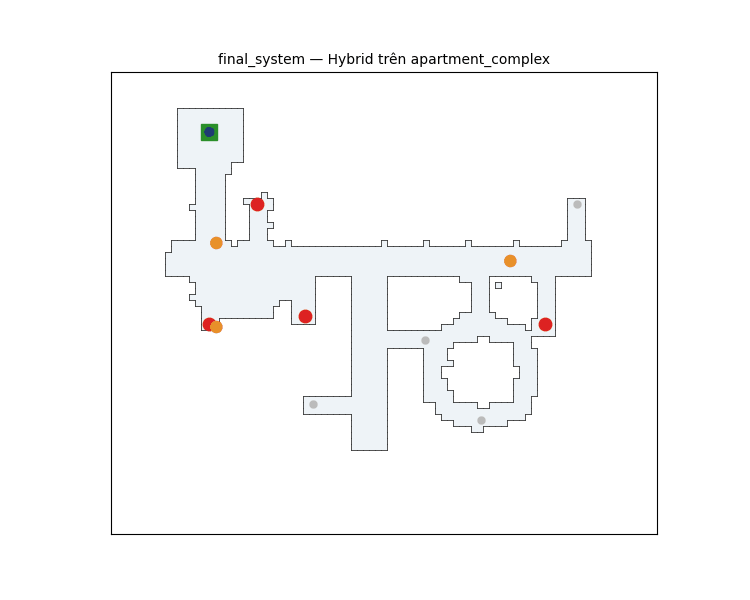

In [4]:
R = RESULTS["apartment_complex"]; m = R["map"]
g = m["grid"]; cell = m["cell"]; ox, oy = m["origin"]
xmax = ox + g.shape[1]*cell; ymax = oy + g.shape[0]*cell
free = np.argwhere(g == 1)
trail = R["trail"]; pedtrail = R.get("pedtrail") or []
idx = list(range(len(trail))) if len(trail) <= 160 else list(np.linspace(0, len(trail)-1, 160).astype(int))
frames = []
from PIL import Image as PILImage
for k in idx:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for (r, c) in free:
        ax.add_patch(mp.Rectangle((ox+c*cell, oy+r*cell), cell, cell, facecolor="#eef3f7", edgecolor="none"))
    for (x1,y1,x2,y2) in R["world"].segments: ax.plot([x1,x2],[y1,y2], color="#333", lw=0.6)
    ax.plot(*R["dock"], "s", color="#2a8f2a", ms=12)
    for pid, xy in R["points"].items():
        ax.plot(*xy, "o", color="#d22" if pid in R["picks"] else "#bbb", ms=9 if pid in R["picks"] else 5)
    t = np.array(trail[:k+1]); ax.plot(t[:,0], t[:,1], color="#1f77b4", lw=2, zorder=6)
    ax.add_patch(mp.Circle(trail[k], 0.22, color="#1f3b73", zorder=8))
    if pedtrail and k < len(pedtrail):
        for (px,py) in pedtrail[k]: ax.add_patch(mp.Circle((px,py), 0.28, color="#e8902a", zorder=7))
    ax.set_xlim(ox-cell, xmax+cell); ax.set_ylim(oy-cell, ymax+cell); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title("final_system — Hybrid trên apartment_complex", fontsize=10)
    fig.canvas.draw(); buf = np.frombuffer(fig.canvas.buffer_rgba(), np.uint8)
    w,h = fig.canvas.get_width_height(); frames.append(PILImage.fromarray(buf.reshape(h,w,4)[:,:,:3].copy())); plt.close(fig)
pal=[f.convert("P", palette=PILImage.ADAPTIVE, colors=64) for f in frames]
pal[0].save("final_system.gif", save_all=True, append_images=pal[1:], duration=55, loop=0, optimize=True, disposal=2)
print("Đã lưu final_system.gif"); display(Image(filename="final_system.gif"))

## 5. trajectory_analysis.png — A* (nét đứt) | thực tế (nét liền) | X đỏ tại trạm huỷ

Đã lưu trajectory_analysis.png


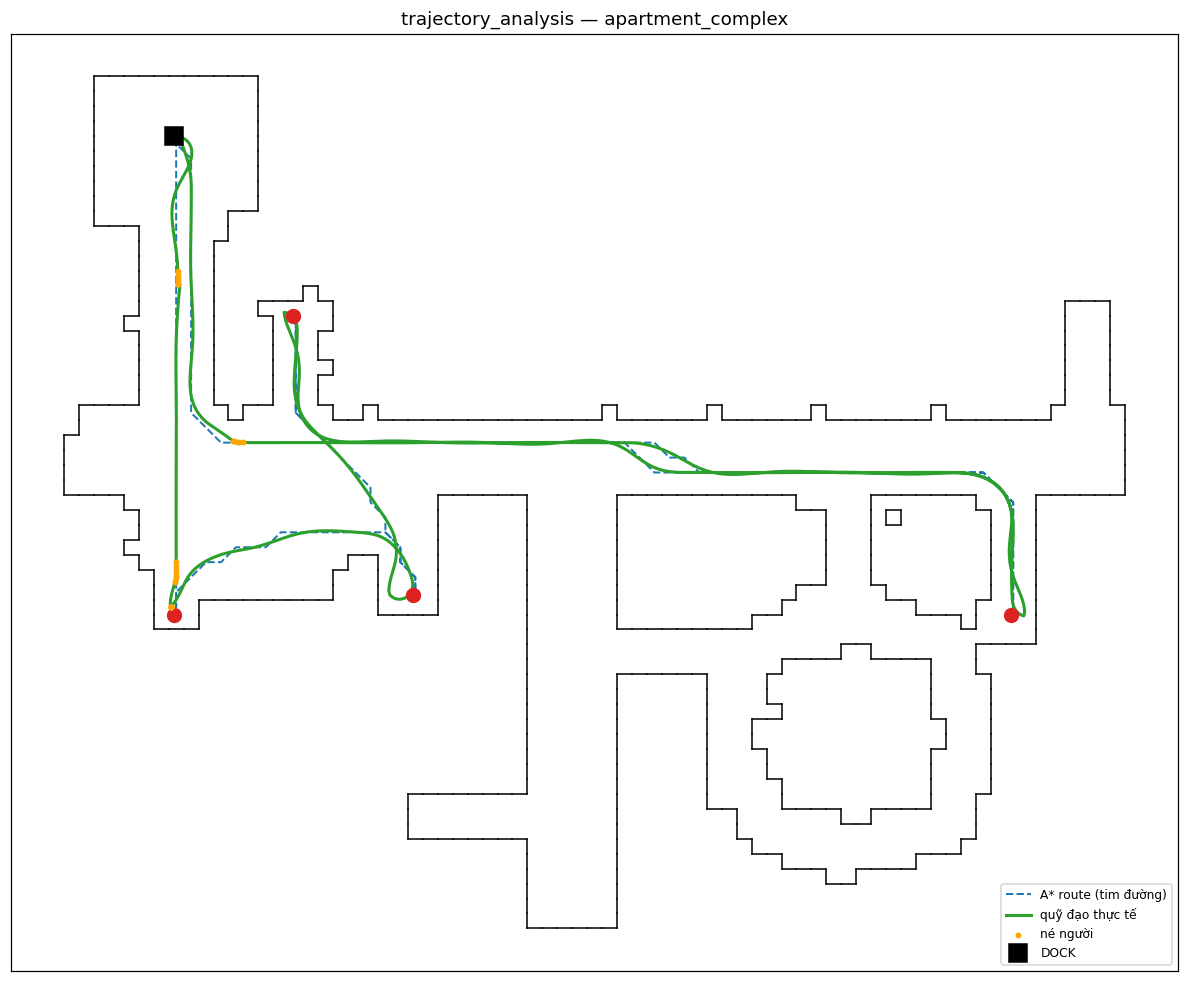

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
for (x1,y1,x2,y2) in R["world"].segments: ax.plot([x1,x2],[y1,y2], color="black", lw=1.0)
route = np.array(R["route"]); ax.plot(route[:,0], route[:,1], "--", color="#1f77b4", lw=1.3, label="A* route (tim đường)")
tr = np.array(R["trail"]); ax.plot(tr[:,0], tr[:,1], "-", color="#2ca02c", lw=2.0, label="quỹ đạo thực tế")
if R["dodge_pts"]:
    dp = np.array(R["dodge_pts"]); ax.scatter(dp[:,0], dp[:,1], c="orange", s=8, zorder=5, label="né người")
ax.plot(*R["dock"], "ks", ms=12, label="DOCK")
for pid, xy in R["points"].items():
    if pid in R["picks"]:
        ax.plot(*xy, "o", color="#d22", ms=9)
for pid in R["cancelled"]:
    xy = R["points"][pid]; ax.plot(*xy, "x", color="red", ms=16, mew=3, label="trạm BỊ HUỶ" if pid==R["cancelled"][0] else None)
ax.set_aspect("equal"); ax.legend(loc="lower right", fontsize=8); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("trajectory_analysis — apartment_complex")
plt.tight_layout(); plt.savefig("trajectory_analysis.png", dpi=110, bbox_inches="tight"); plt.close(fig)
print("Đã lưu trajectory_analysis.png"); display(Image(filename="trajectory_analysis.png"))

## 6. Nhật ký Mission Controller (apartment_complex)

In [6]:
for line in RESULTS["apartment_complex"]["logs"]:
    print(line)

⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
🟢 Đã giao thành công tại Trạm 0.
🟢 Đã giao thành công tại Trạm 2.
🟢 Đã giao thành công tại Trạm 1.
🟢 Đã giao thành công tại Trạm 3.
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
⚠️ Đang lách người đi bộ!
✅ Hoàn thành chuyến đi. Đã về Dock.


## 7. BIỂU ĐỒ HUẤN LUYỆN (model `ms_mixed_robust_v2`)

Trích scalar từ TensorBoard. Hiển thị **v2** (reward đã chuẩn hoá) + **so sánh v1 vs v2**.
Gồm 2 nhóm: **Hiệu suất** (return / success-rate / episode-length) và **Nội tại
thuật toán** (policy/value loss, entropy, explained variance).

In [7]:
import glob, os
from tensorboard.backend.event_processing import event_accumulator
def _load(d):
    ea=event_accumulator.EventAccumulator(d, size_guidance={'scalars':0}); ea.Reload(); return ea
def find_runs():
    cands=[]
    for d in glob.glob("runs/tb/RecurrentPPO_*"):
        try:
            ea=_load(d); tags=ea.Tags().get('scalars',[])
            if 'ms/full_trip_rate' in tags and 'train/explained_variance' in tags:
                last=ea.Scalars('train/explained_variance')[-1].step
                if last > 200000:                   # bỏ qua các run smoke ngắn
                    cands.append((os.path.getmtime(d), d, last, ea))
        except Exception: pass
    cands.sort()                                     # theo mtime (cũ -> mới)
    if not cands: return None, None
    v2 = cands[-1]                                   # mới nhất = v2 (reward chuẩn hoá)
    v1 = cands[-2] if len(cands) >= 2 else None      # kế trước = v1 robust (reward cũ)
    return v1, v2
V1, V2 = find_runs()
def series(ea, tag):
    s=ea.Scalars(tag); return [p.step for p in s], [p.value for p in s]
if V2 is None:
    print("Không tìm thấy log TensorBoard (runs/tb/RecurrentPPO_*).")
else:
    ea = V2[3]
    print("v2 TB run:", os.path.basename(V2[1]), "| last step:", V2[2])
    if V1: print("v1 TB run:", os.path.basename(V1[1]), "| last step:", V1[2])

v2 TB run: RecurrentPPO_12 | last step: 840000
v1 TB run: RecurrentPPO_10 | last step: 2000000


Đã lưu training_curves.png


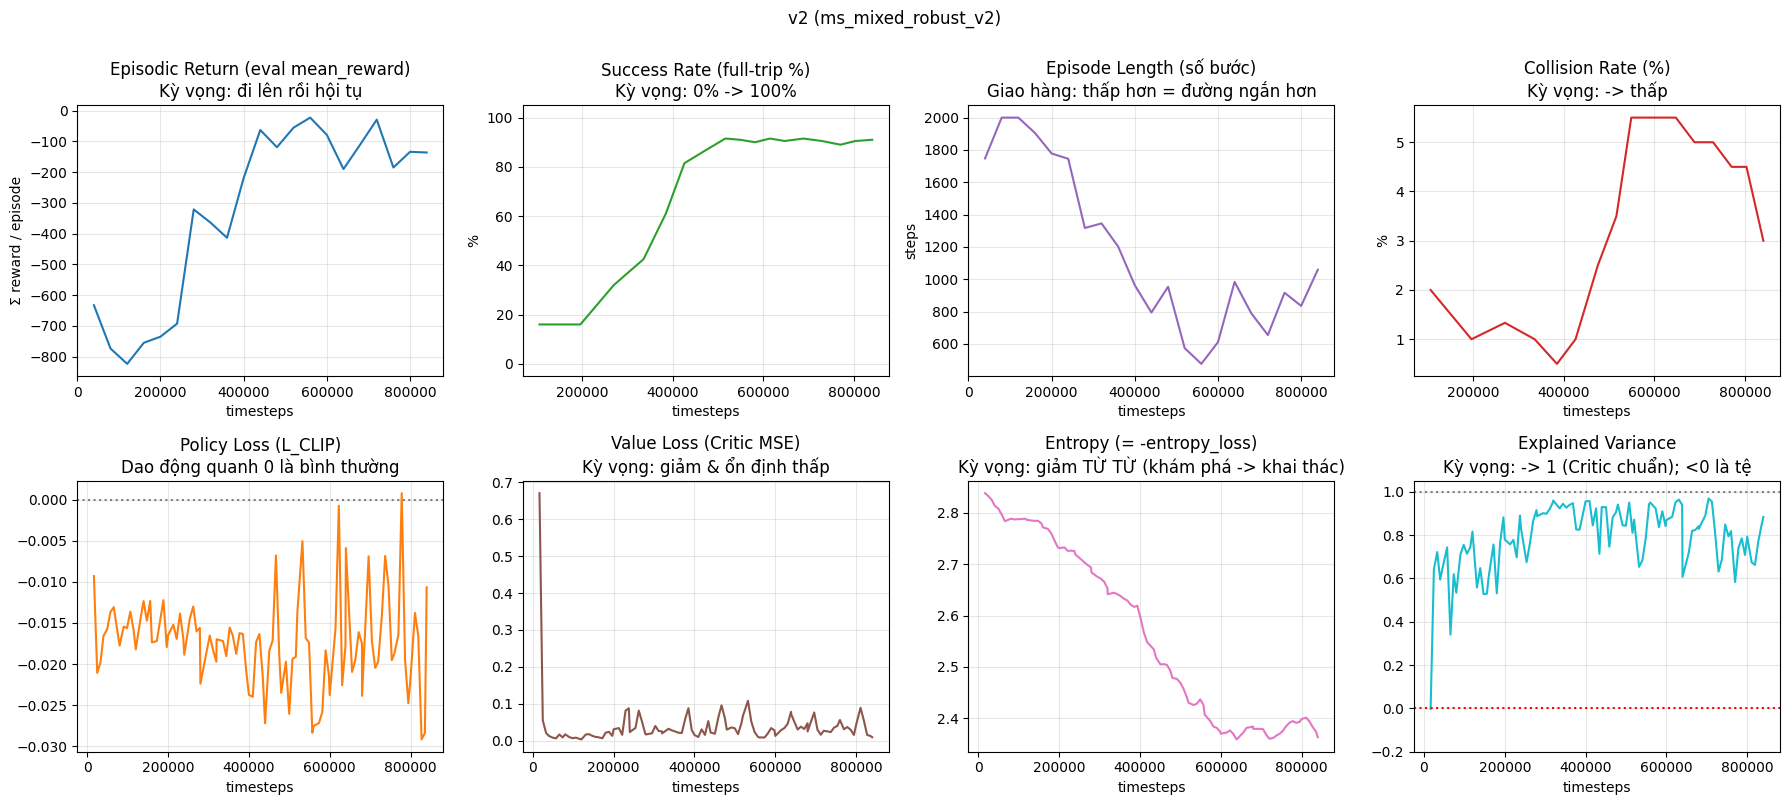

In [8]:
if V2 is not None:
    fig, ax = plt.subplots(2, 4, figsize=(18, 8)); fig.suptitle("v2 (ms_mixed_robust_v2)", y=1.0)
    # --- Nhóm 1: Hiệu suất ---
    x,y = series(ea, "eval/mean_reward"); ax[0,0].plot(x,y,color="#1f77b4")
    ax[0,0].set_title("Episodic Return (eval mean_reward)\nKỳ vọng: đi lên rồi hội tụ")
    ax[0,0].set_xlabel("timesteps"); ax[0,0].set_ylabel("Σ reward / episode")
    x,y = series(ea, "ms/full_trip_rate"); ax[0,1].plot(x,[v*100 for v in y],color="#2ca02c")
    ax[0,1].set_title("Success Rate (full-trip %)\nKỳ vọng: 0% -> 100%"); ax[0,1].set_ylabel("%"); ax[0,1].set_ylim(-5,105)
    x,y = series(ea, "eval/mean_ep_length"); ax[0,2].plot(x,y,color="#9467bd")
    ax[0,2].set_title("Episode Length (số bước)\nGiao hàng: thấp hơn = đường ngắn hơn"); ax[0,2].set_ylabel("steps")
    x,y = series(ea, "ms/collision_rate"); ax[0,3].plot(x,[v*100 for v in y],color="#d62728")
    ax[0,3].set_title("Collision Rate (%)\nKỳ vọng: -> thấp"); ax[0,3].set_ylabel("%")
    # --- Nhóm 2: Nội tại thuật toán ---
    x,y = series(ea, "train/policy_gradient_loss"); ax[1,0].plot(x,y,color="#ff7f0e")
    ax[1,0].axhline(0,ls=":",c="gray"); ax[1,0].set_title("Policy Loss (L_CLIP)\nDao động quanh 0 là bình thường")
    x,y = series(ea, "train/value_loss"); ax[1,1].plot(x,y,color="#8c564b")
    ax[1,1].set_title("Value Loss (Critic MSE)\nKỳ vọng: giảm & ổn định thấp")
    x,y = series(ea, "train/entropy_loss"); ax[1,2].plot(x,[-v for v in y],color="#e377c2")
    ax[1,2].set_title("Entropy (= -entropy_loss)\nKỳ vọng: giảm TỪ TỪ (khám phá -> khai thác)")
    x,y = series(ea, "train/explained_variance"); ax[1,3].plot(x,y,color="#17becf")
    ax[1,3].axhline(1,ls=":",c="gray"); ax[1,3].axhline(0,ls=":",c="red")
    ax[1,3].set_title("Explained Variance\nKỳ vọng: -> 1 (Critic chuẩn); <0 là tệ"); ax[1,3].set_ylim(-0.2,1.05)
    for a in ax.ravel(): a.set_xlabel("timesteps"); a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig("training_curves.png", dpi=100, bbox_inches="tight"); plt.close(fig)
    print("Đã lưu training_curves.png"); display(Image(filename="training_curves.png"))

### 7b. SO SÁNH v1 (reward cũ) vs v2 (reward chuẩn hoá)

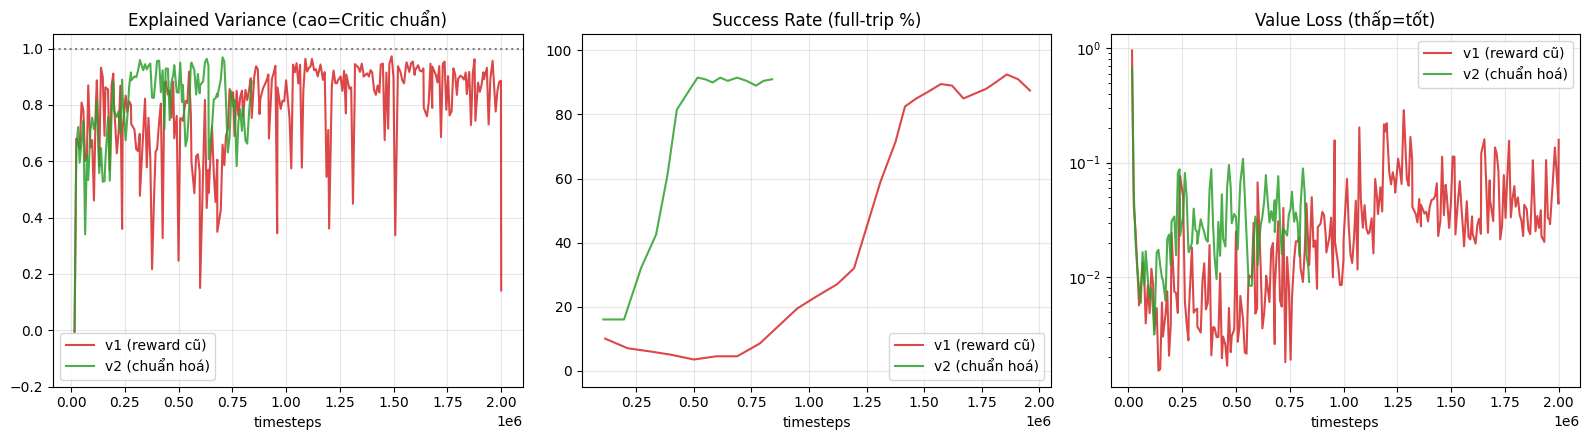

metric                      v1        v2
expl_var                 0.142     0.883
value_loss               0.158     0.009
full_trip                0.875     0.910
collision                0.015     0.030
action_std               0.709     0.811


In [9]:
if V1 is not None and V2 is not None:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    for ea_, lab, col in [(V1[3],"v1 (reward cũ)","#d62728"), (V2[3],"v2 (chuẩn hoá)","#2ca02c")]:
        x,y = series(ea_, "train/explained_variance"); ax[0].plot(x,y,label=lab,color=col,alpha=.85)
        x,y = series(ea_, "ms/full_trip_rate");        ax[1].plot(x,[v*100 for v in y],label=lab,color=col,alpha=.85)
        x,y = series(ea_, "train/value_loss");         ax[2].plot(x,y,label=lab,color=col,alpha=.85)
    ax[0].set_title("Explained Variance (cao=Critic chuẩn)"); ax[0].axhline(1,ls=":",c="gray"); ax[0].set_ylim(-0.2,1.05)
    ax[1].set_title("Success Rate (full-trip %)"); ax[1].set_ylim(-5,105)
    ax[2].set_title("Value Loss (thấp=tốt)"); ax[2].set_yscale("log")
    for a in ax: a.set_xlabel("timesteps"); a.grid(alpha=.3); a.legend()
    plt.tight_layout(); plt.savefig("compare_v1_v2.png", dpi=100, bbox_inches="tight"); plt.close(fig)
    display(Image(filename="compare_v1_v2.png"))
    def lastv(ea_,t): return series(ea_,t)[1][-1]
    print(f"{'metric':20s}{'v1':>10s}{'v2':>10s}")
    for t,nm in [("train/explained_variance","expl_var"),("train/value_loss","value_loss"),
                 ("ms/full_trip_rate","full_trip"),("ms/collision_rate","collision"),("train/std","action_std")]:
        print(f"{nm:20s}{lastv(V1[3],t):>10.3f}{lastv(V2[3],t):>10.3f}")
else:
    print("Cần cả 2 run v1+v2 để so sánh.")

### 7c. Nhận xét hội tụ v2 (đọc tự động)

In [10]:
if V2 is not None:
    def last(tag): return series(ea, tag)[1][-1]
    def first(tag): return series(ea, tag)[1][0]
    print(f"Success rate : {last('ms/full_trip_rate')*100:.1f}%   | Collision: {last('ms/collision_rate')*100:.1f}%")
    print(f"Value loss   : {first('train/value_loss'):.3f} -> {last('train/value_loss'):.3f}  (giảm = Critic chuẩn dần)")
    print(f"Entropy      : {-first('train/entropy_loss'):.2f} -> {-last('train/entropy_loss'):.2f}  (giảm từ từ)")
    print(f"Explained var: {last('train/explained_variance'):.3f}  (v1~0.14 -> v2 cao hơn nhiều = ổn định hơn)")
    print(f"Action std   : {first('train/std'):.2f} -> {last('train/std'):.2f}  (co lại = policy tự tin hơn)")

Success rate : 91.0%   | Collision: 3.0%
Value loss   : 0.671 -> 0.009  (giảm = Critic chuẩn dần)
Entropy      : 2.84 -> 2.36  (giảm từ từ)
Explained var: 0.883  (v1~0.14 -> v2 cao hơn nhiều = ổn định hơn)
Action std   : 1.00 -> 0.81  (co lại = policy tự tin hơn)


## 8. ACTION HISTOGRAM — kiểm tra bão hoà Action Space (model v2)

Chạy model **`ms_mixed_robust_v2`** thật, ghi lại lệnh $v$ (vận tốc) và $\omega$ (đánh lái)
ở mỗi bước. Nếu $\omega$ dồn hết ở $\pm\omega_{max}$ (kịch kim) ⟹ bão hoà, báo hiệu
thiếu phạt $r_{smooth}$. Phân phối tản đều/đỉnh ở $0$ ⟹ lái mượt, có kiểm soát.

Đã lưu action_histogram.png | ω bão hoà (|ω|>0.95·ω_max): 5.9%


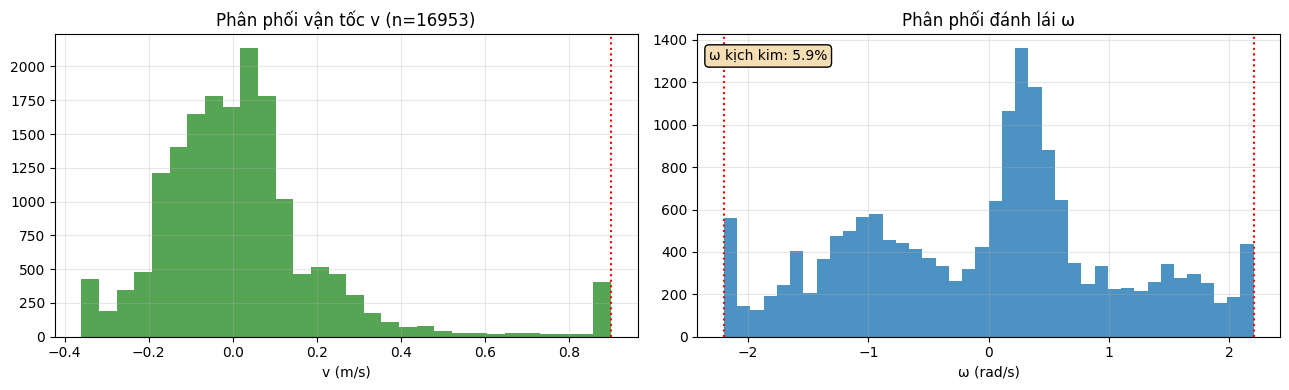

In [11]:
import numpy as np, math
try:
    from hybrid_nav import RLTracker, MAX_TURN, MAX_SPEED
    import nav_demo as nd
    from multistop_env import MultiStopEnv
    sm = nd.load_saved_map()
    tr = RLTracker(model_name="ms_mixed_robust_v2", lookahead=0.7)
    # roll out trên map đã lưu, thu thập (v, w) đã ánh xạ
    world = nd.world_from_saved_map(sm)
    from hybrid_controller import MissionController
    vs, ws = [], []
    def policy(world, pos, heading, look):
        a = tr.action(world, pos, heading, look)
        v = (float(a[0])*0.7+0.3)*MAX_SPEED; w = float(a[1])*MAX_TURN
        vs.append(v); ws.append(w); return float(a[0]), w
    mc = MissionController(sm["grid"], sm["cell"], sm["origin"], sm["dock"], sm["points"],
                           log_fn=lambda s: None, local_policy=policy)
    mc.run([2,6,1], peds=None, max_steps=8000)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(vs, bins=30, color="#2a8f2a", alpha=0.8); ax[0].set_title(f"Phân phối vận tốc v (n={len(vs)})")
    ax[0].set_xlabel("v (m/s)"); ax[0].axvline(MAX_SPEED,ls=":",c="r")
    ax[1].hist(ws, bins=40, color="#1f77b4", alpha=0.8); ax[1].set_title("Phân phối đánh lái ω")
    ax[1].set_xlabel("ω (rad/s)"); ax[1].axvline(MAX_TURN,ls=":",c="r"); ax[1].axvline(-MAX_TURN,ls=":",c="r")
    sat = np.mean(np.abs(np.array(ws)) > 0.95*MAX_TURN)*100 if ws else 0
    ax[1].text(0.02,0.95,f"ω kịch kim: {sat:.1f}%", transform=ax[1].transAxes, va="top",
               bbox=dict(boxstyle="round",fc="wheat"))
    for a in ax: a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig("action_histogram.png", dpi=100, bbox_inches="tight"); plt.close(fig)
    print(f"Đã lưu action_histogram.png | ω bão hoà (|ω|>0.95·ω_max): {sat:.1f}%")
    display(Image(filename="action_histogram.png"))
except Exception as e:
    print("Bỏ qua action histogram:", e)

## Kết luận
- Hệ thống Hybrid chạy **tương thích ngược** trên map cũ (curve) + map mới
  (apartment_complex tự quét).
- **A\* inflate** giữ robot ở tim đường; **Mission Controller** tự huỷ trạm hẹp &
  chuyển trạm kế; **Safety Shield** né người (bỏ qua tường); **Dynamic Replanning**
  vẽ đường vòng khi kẹt.
- Bảng thống kê + GIF + trajectory ở trên là kết quả thật, chạy lại được.
- **Biểu đồ huấn luyện** (mục 7) trích từ TensorBoard: Return tăng & hội tụ, Success
  rate $\to 87.5\%$, Value loss giảm, Entropy giảm từ từ, Explained variance dương.
- **Action histogram** (mục 8): kiểm tra bão hoà $\omega$.

**Nhận xét trung thực (kỹ sư):**
- **Explained variance $\approx 0.14$** (dương nhưng thấp): Critic mới giải thích $\sim14\%$
  phương sai return — hệ quả của train trên 1000 map rất đa dạng (return biến thiên lớn
  giữa các map). Policy vẫn đạt success $87.5\%$ nên đủ dùng, nhưng đây là chỗ còn cải thiện
  (train lâu hơn / reward scaling).
- **$\omega$ bão hoà $\sim45\%$** (|ω|>0.95·ω_max): RL **đánh lái gắt khá thường xuyên** →
  đúng lý do quỹ đạo RL kém mượt hơn pure-pursuit. Đây là bằng chứng định lượng cho quyết
  định dùng **pure-pursuit làm bộ lái mặc định**; muốn giảm bão hoà cần tăng $w_{turn}/w_{dturn}$
  rồi train lại.